## 探索的データ分析ノートブック(デッキ)

- ２つのデッキを入力としたデッキの相性予測AIを構築する上で、ベクトル空間上で各デッキをうまく配置し、分類できるようなデッキエンコーダを作成する必要がある。そこで、デッキをベクトル空間上でうまく分類できるエンコーダモデルは何なのかを考える。

- **仮説１**：デッキのアイデンティティを学習するためにはデッキ中の全８枚のカードの関係性を理解する必要がある。そこで、transformerのAttention機構を用いたマスク処理による自己教師あり学習によって事前学習モデルを構築することが有効なのではないか    
    - 例１：ゴブリンバレルはゴブリンギャングと相性がいい
    - 例２：コストの異なる呪文は同時起用されやすい（ファイアボールとザップ）

- **仮説２**：クラロワのデッキにはカード８枚の位置関係は関係ない。そこで位置エンコーディングを完全に消去する必要がある。

- **仮説３**：デッキのコストに関する統計量はノイズになってしまうのではないか。例えば、ゴーレムデッキとラヴァハウンドデッキはデッキの平均コストや標準偏差等の統計量が似ることがあるが、本来、この２デッキは使われるカードは全く異なり、ベクトル空間上で近くに配置されるべきではないのだ。
    

In [50]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import os
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
import torch
import sys
import torch
import random
import math
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report   

plt.rcParams['font.family'] = 'Hiragino Sans'

### データの読み込み（デッキデータ）

- `src/collect_decks.py`より上位ランキングのプレイヤーの使用デッキから芋蔓式にデッキを収集した。

In [6]:

csv_path = os.path.join('../data/ranking_train.csv')
json_path = os.path.join('../data/cards.json')

df = pd.read_csv(csv_path)

with open(json_path, 'r', encoding='utf-8') as f:
    cards_data = json.load(f)
    
# ID -> 名前 のマッピング辞書
id_to_name = {}
for card_id_str, name_info in cards_data.items():
    if isinstance(name_info, dict) and "name" in name_info:
        id_to_name[int(card_id_str)] = name_info["name"]
    else:
        id_to_name[int(card_id_str)] = str(name_info)

# card1 ~ card8 の列だけを抽出してリスト化
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'card7', 'card8']
decks = df[card_cols].values.tolist()

# IDを名前に変換
decks_names = []
for deck in decks:
    decks_names.append([id_to_name.get(card_id, f"Unknown({card_id})") for card_id in deck])

print(f" {len(decks_names)} 件のデッキデータを読み込みました")
print(pd.DataFrame(decks_names).head(5))

 619647 件のデッキデータを読み込みました
            0               1               2               3  \
0   Hog Rider          Guards     Executioner  Electro Spirit   
1   Skeletons  Giant Skeleton     Dart Goblin            Bats   
2     Goblins          Wizard  Giant Skeleton     Dark Prince   
3  Lumberjack     Royal Ghost         Zappies     Cannon Cart   
4       Witch        Valkyrie       Berserker      Goblin Hut   

                 4               5                 6               7  
0        Berserker       Lightning  Barbarian Barrel  Giant Snowball  
1  Skeleton Barrel  Electro Spirit           The Log           Clone  
2       Battle Ram     Royal Ghost      Mother Witch           Vines  
3    Golden Knight    Mother Witch  Barbarian Barrel     Heal Spirit  
4           Poison       Graveyard  Barbarian Barrel           Vines  


### 全カード使用率の可視化
- カードの使用率ランキングを見ると、上位にランクインする条件はローリングウッドや矢の雨などの汎用的な呪文カードや、メガナイトやホグライダーなど環境的に優位なパワーカードが上位ランキングを占めていることがわかる。特に、ローリングウッドに至っては全データ中の約25%を占めていることから、汎用的な呪文群をどのようにデッキ内で評価するかが鍵になるのではないか。ある程度汎用性があり、様々なデッキタイプに採用される呪文カード等は特徴量としてノイズになりうると仮説立てる。

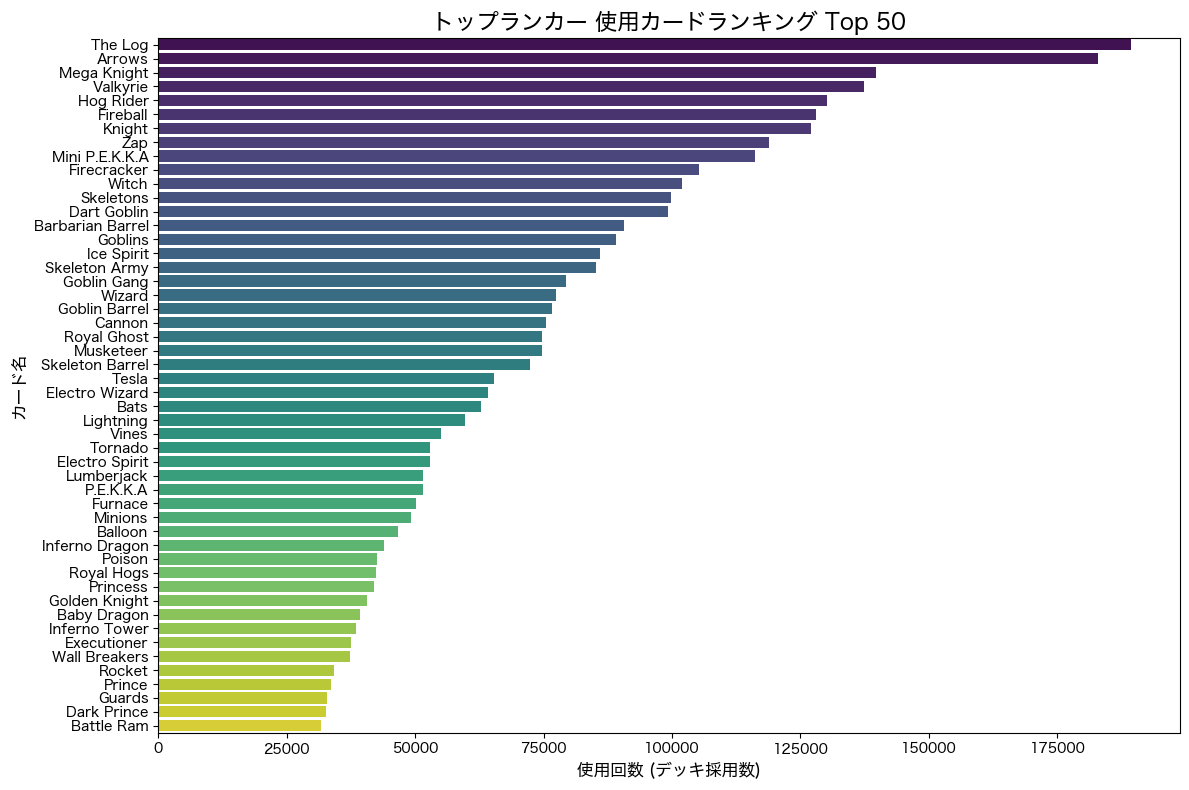

In [8]:
all_cards = [card for deck in decks_names for card in deck]
card_counts = Counter(all_cards)

top_50 = card_counts.most_common(50)
top_50_names = [x[0] for x in top_50]
top_50_counts = [x[1] for x in top_50]

plt.figure(figsize=(12, 8))


sns.barplot(
    x=top_50_counts, 
    y=top_50_names, 
    hue=top_50_names, 
    palette='viridis', 
    legend=False
)

plt.title('トップランカー 使用カードランキング Top 50', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('カード名', fontsize=12)
plt.tight_layout()
plt.show()

### ランクインしたカードの組み合わせヒートマップ
- デッキを考える上で組み合わせという観点は非常に重要であり、例えばローリングウッドはホグライダーやスケルトンなどの低コストユニットと同時起用されることがわかる。デッキ全体のコストという観点ではノイズになりうると仮説立てたが、カード同士のシナジーを考える上では、コストという概念は非常に重要なのかもしれない。加えて、高コストのユニットは同時起用されずらいことも考慮するべきである。


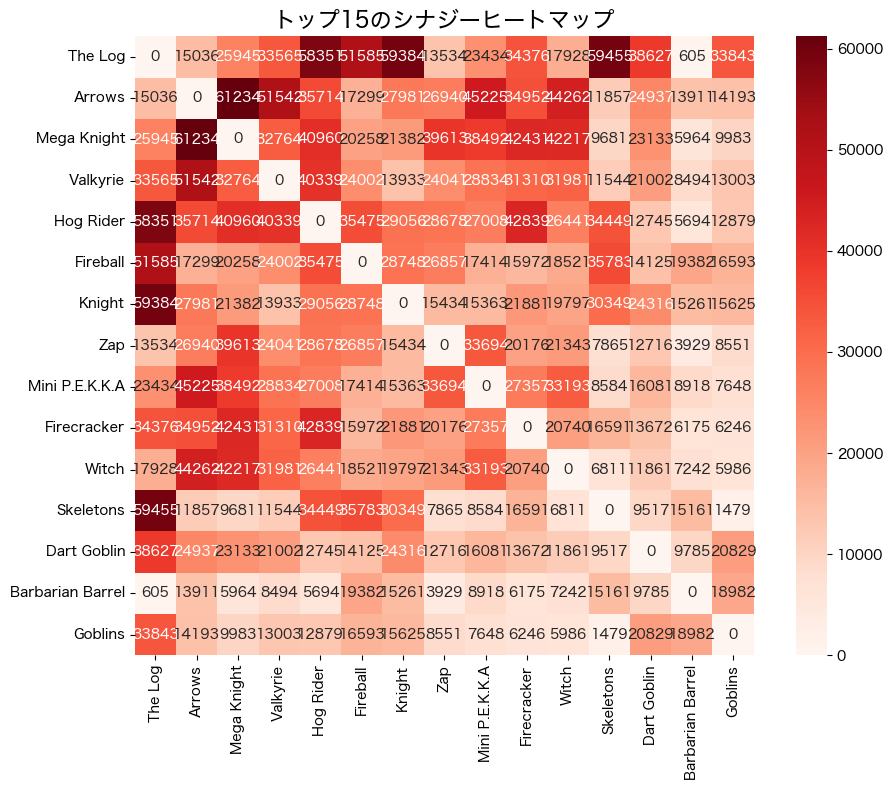

In [10]:
pair_counts = Counter()
for deck in decks_names:
    for pair in combinations(sorted(deck), 2):
        pair_counts[pair] += 1

top_15_names = [x[0] for x in card_counts.most_common(15)]
synergy_df = pd.DataFrame(0, index=top_15_names, columns=top_15_names)

for (card1, card2), count in pair_counts.items():
    if card1 in top_15_names and card2 in top_15_names:
        synergy_df.at[card1, card2] = count
        synergy_df.at[card2, card1] = count # 対称行列にする

# 対角成分（同じカード同士）は0にして色を抜く
for name in top_15_names:
    synergy_df.at[name, name] = 0

plt.figure(figsize=(10, 8))
sns.heatmap(synergy_df, annot=True, fmt='d', cmap='Reds', square=True)
plt.title('トップ15のシナジーヒートマップ', fontsize=16)
plt.tight_layout()
plt.show()

### ユニットカードの使用率の可視化
- 全カードでもそうだったようにユニットカードの使用率が上がる条件はある程度汎用的なカードか、バランス調整や進化の実装等による圧倒的なカードパワーを持つカードかの２択であることがわかった。今回はデータを１ヶ月のみの場合でデータ収集したが、複数の月にまたがってデータ収集を行った場合、注意が必要である。

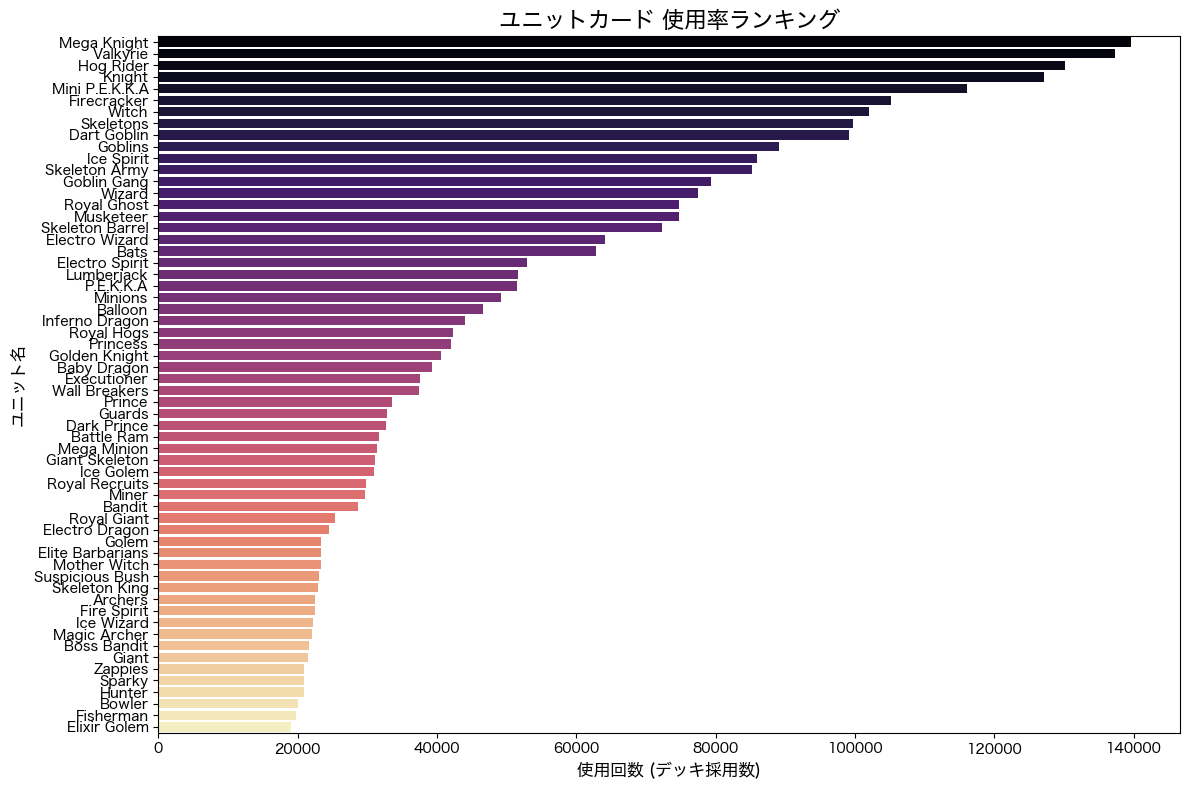

In [17]:
# ==========================================
# 1. デッキから「ユニット（IDが26000000番台）」だけを抽出
# ==========================================
unit_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    unit_deck = []
    for card_id in deck_ids:
        # IDが '26' から始まるものをユニットとして判定
        if str(card_id).startswith('26'): 
            unit_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    unit_decks_names.append(unit_deck)

# ==========================================
# 2. ユニットの使用率ランキング
# ==========================================
all_units = [unit for deck in unit_decks_names for unit in deck]
unit_counts = Counter(all_units)

top_units = unit_counts.most_common(60) 
top_unit_names = [x[0] for x in top_units]
top_unit_counts = [x[1] for x in top_units]

plt.figure(figsize=(12, 8))
# ユニットっぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_unit_counts, y=top_unit_names, hue=top_unit_names, palette='magma', legend=False)
plt.title('ユニットカード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('ユニット名', fontsize=12)
plt.tight_layout()
plt.show()


### 呪文カードの使用率の可視化
- ユニットカードに比べて呪文は比較的採用率が高く、種類も絞られがちであることがわかる。上位５つの呪文たちはどんなデッキタイプにも入ることから、ベクトル空間上でどう配置するかが重要である。できるだけ中央に配置されるのではないか

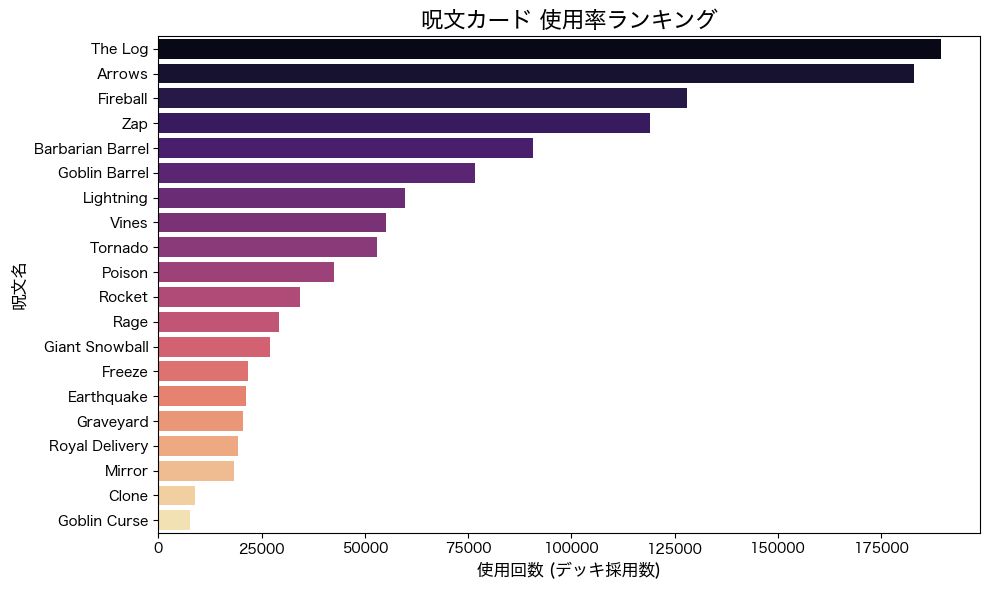

In [ ]:
# ==========================================
# 1. デッキから「呪文（IDが28000000番台）」だけを抽出
# ==========================================
spell_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    spell_deck = []
    for card_id in deck_ids:
        # IDが '28' から始まるものを呪文として判定
        if str(card_id).startswith('28'): 
            spell_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    spell_decks_names.append(spell_deck)

# ==========================================
# 2. 呪文の使用率ランキング
# ==========================================
all_spells = [spell for deck in spell_decks_names for spell in deck]
spell_counts = Counter(all_spells)

# 呪文は全体の枚数が少ないので、トップ20
top_spells = spell_counts.most_common(20) 
top_spell_names = [x[0] for x in top_spells]
top_spell_counts = [x[1] for x in top_spells]

plt.figure(figsize=(10, 6))
# 呪文っぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_spell_counts, y=top_spell_names, hue=top_spell_names, palette='magma', legend=False)
plt.title('呪文カード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('呪文名', fontsize=12)
plt.tight_layout()
plt.show()


### 呪文の組み合わせヒートマップ
- 基本的にはザップやローリングバーバリアンなどの軽量呪文とファイアボールやライトニングなどの重量呪文の組み合わせ、もしくは単体での使用が多いことがわかった。特に矢の雨は単体での採用率が高く、矢の雨が入っているデッキはユニットでのコントロールデッキが高いということが仮説立てられる。

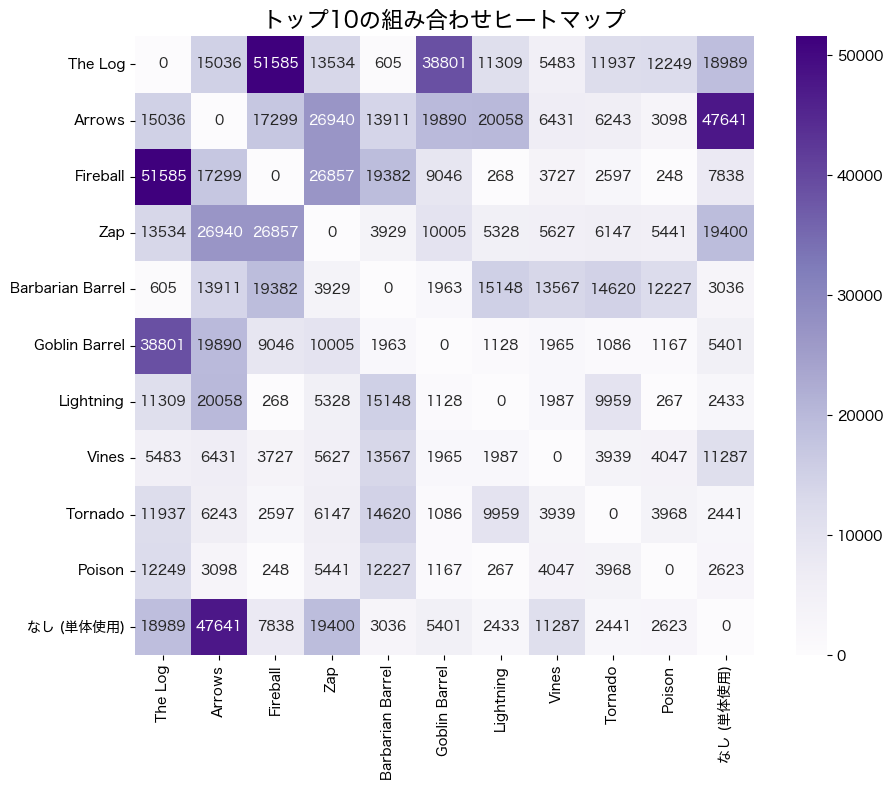

In [13]:
spell_pair_counts = Counter()
for deck in spell_decks_names:
    if len(deck) == 0:
        continue # 呪文0枚の超特異デッキはスキップ
    elif len(deck) == 1:
        # 呪文が1枚だけの場合、「なし (単体使用)」とのコンビとして集計！
        spell_pair_counts[(deck[0], 'なし (単体使用)')] += 1
    else:
        # 呪文が2枚以上の場合は通常の組み合わせ
        for pair in combinations(sorted(deck), 2):
            spell_pair_counts[pair] += 1

# トップ10の呪文に「なし (単体使用)」を加えて、ヒートマップの枠組みを作る
top_10_spells = [x[0] for x in spell_counts.most_common(10)]
heatmap_labels = top_10_spells + ['なし (単体使用)']

spell_synergy_df = pd.DataFrame(0, index=heatmap_labels, columns=heatmap_labels)

for (spell1, spell2), count in spell_pair_counts.items():
    # 抽出したラベルの中にある組み合わせだけをDataFrameに入れる
    if spell1 in heatmap_labels and spell2 in heatmap_labels:
        spell_synergy_df.at[spell1, spell2] = count
        spell_synergy_df.at[spell2, spell1] = count

# 対角成分（同じ呪文同士）は0にして色を抜く
for name in heatmap_labels:
    spell_synergy_df.at[name, name] = 0

plt.figure(figsize=(10, 8)) # 「なし」が増えた分、少しだけ図を大きくしました
sns.heatmap(spell_synergy_df, annot=True, fmt='d', cmap='Purples', square=True)
plt.title('トップ10の組み合わせヒートマップ', fontsize=16)
plt.tight_layout()
plt.show()

### 建物カード使用率の可視化

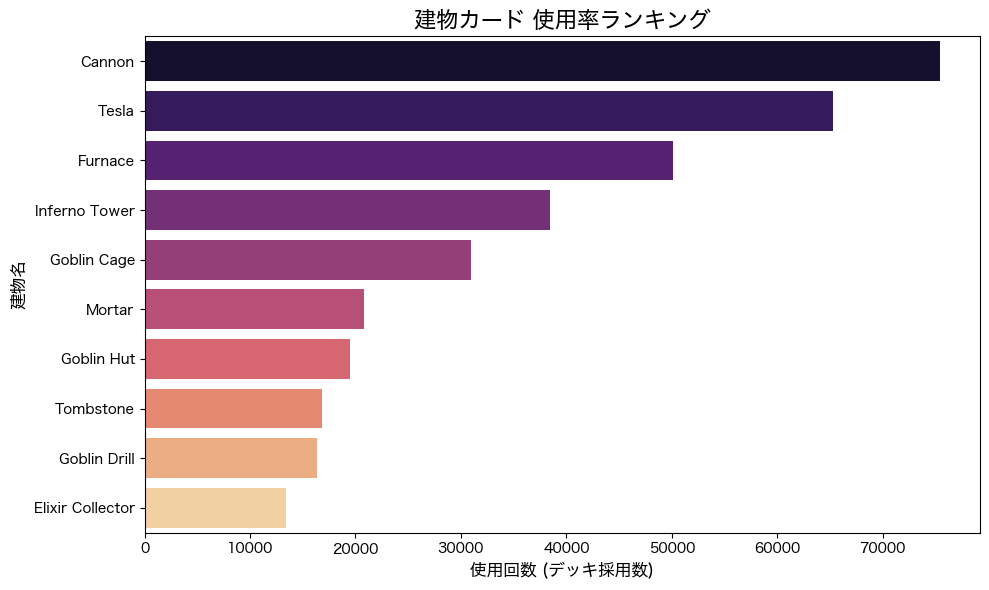

In [14]:
# ==========================================
# 1. デッキから「建物（IDが27000000番台）」だけを抽出
# ==========================================
building_decks_names = []
for deck_ids in decks: # decks は [26000021, 28000011, ...] のような生IDのリスト
    building_deck = []
    for card_id in deck_ids:
        # IDが '27' から始まるものを建物として判定
        if str(card_id).startswith('27'): 
            building_deck.append(id_to_name.get(card_id, f"Unknown({card_id})"))
    building_decks_names.append(building_deck)

# ==========================================
# 2. 建物の使用率ランキング
# ==========================================
all_buildings = [building for deck in building_decks_names for building in deck]
building_counts = Counter(all_buildings)

# 建物は全体の枚数が少ないので、トップ10
top_buildings = building_counts.most_common(10) 
top_building_names = [x[0] for x in top_buildings]
top_building_counts = [x[1] for x in top_buildings]

plt.figure(figsize=(10, 6))
# 建物っぽさを出すために色を 'magma' (紫〜オレンジ) に変更
sns.barplot(x=top_building_counts, y=top_building_names, hue=top_building_names, palette='magma', legend=False)
plt.title('建物カード 使用率ランキング', fontsize=16)
plt.xlabel('使用回数 (デッキ採用数)', fontsize=12)
plt.ylabel('建物名', fontsize=12)
plt.tight_layout()
plt.show()


## デッキエンコーダによる埋め込みベクトルの可視化(T-SNE)
8枚のカードからなるデッキをエンコードする簡単なモデルを組み、Transformer機構によるベクトル空間への写像の優位性を考えることが目的である。

### 主軸カードによるデッキ分類
- クラロワのデッキには攻めの主軸となるメインカード（ホグライダー、ゴーレム...）が存在する。今回の可視化ではそれらのカードをクラスとして扱い、デッキを分類する。また、これらのカードをクラスラベルとして扱うことで全データ中の94.7％のデータが網羅されていることが確認できる。
- **デッキの埋め込みベクトル空間において必ずしもメインカードによるラベリングが最適であるとは限らず、transformerによる埋め込みベクトルはより高度な特徴量を保持していることが考えられる。**

### One-Hotエンコーディングによるベクトル空間の可視化
- 比較対象となるデッキエンコードモデルとして、最もシンプルなOne-Hotエンコーディングを実装した。
- 全カード122枚、つまり122次元ベクトルの内、デッキに使用されているカードの要素のみを１として定義し実装するやり方である。
- 考察
    - 外側には一部メインカードでのクラスタリングに成功しているクラスが多数あった（枯渇系、建物系、ロイヤルジャイアント...）。このことから、One-Hotエンコーディングにおいて、強烈なアイデンティティを持つメインカードを有するデッキはベクトル空間上でクラスタを形成しやすく、汎用カードの呪文等のノイズを無視できるのではないか。
    - 枯渇デッキなどはある程度型が完成しており、(ゴブリンバレル、ゴブリンギャング、プリンセス)同じカードの被りが起きるとベクトル空間で近づきやすいことから、ある程度固定されたデッキタイプはクラスタリングしやすいのではないか。
    - 一方で中央には使用率トップのメガナイトやホグライダーなどのパワーカードが散らばっておりうまくクラスタを形成できていない。使用率が多いということはデッキパターンも多いことが考えられ、One-Hotエンコーディングによるエンコーディングはメインカードとサブカードの細かな関係の違いを埋め込みづらいのではないか。

全 619647 件中、ランダムに抽出した 3000 件を処理します。
📊 --- 主軸カードの網羅率レポート ---
全データ数: 3000 デッキ
単一主軸デッキ: 1715 (57.2%)
複数主軸デッキ: 1127 (37.6%)
主軸なしデッキ: 158 (5.3%)
分類成功率（網羅率）: 94.7%
------------------------------------

デッキをベクトル化し、t-SNEを実行中


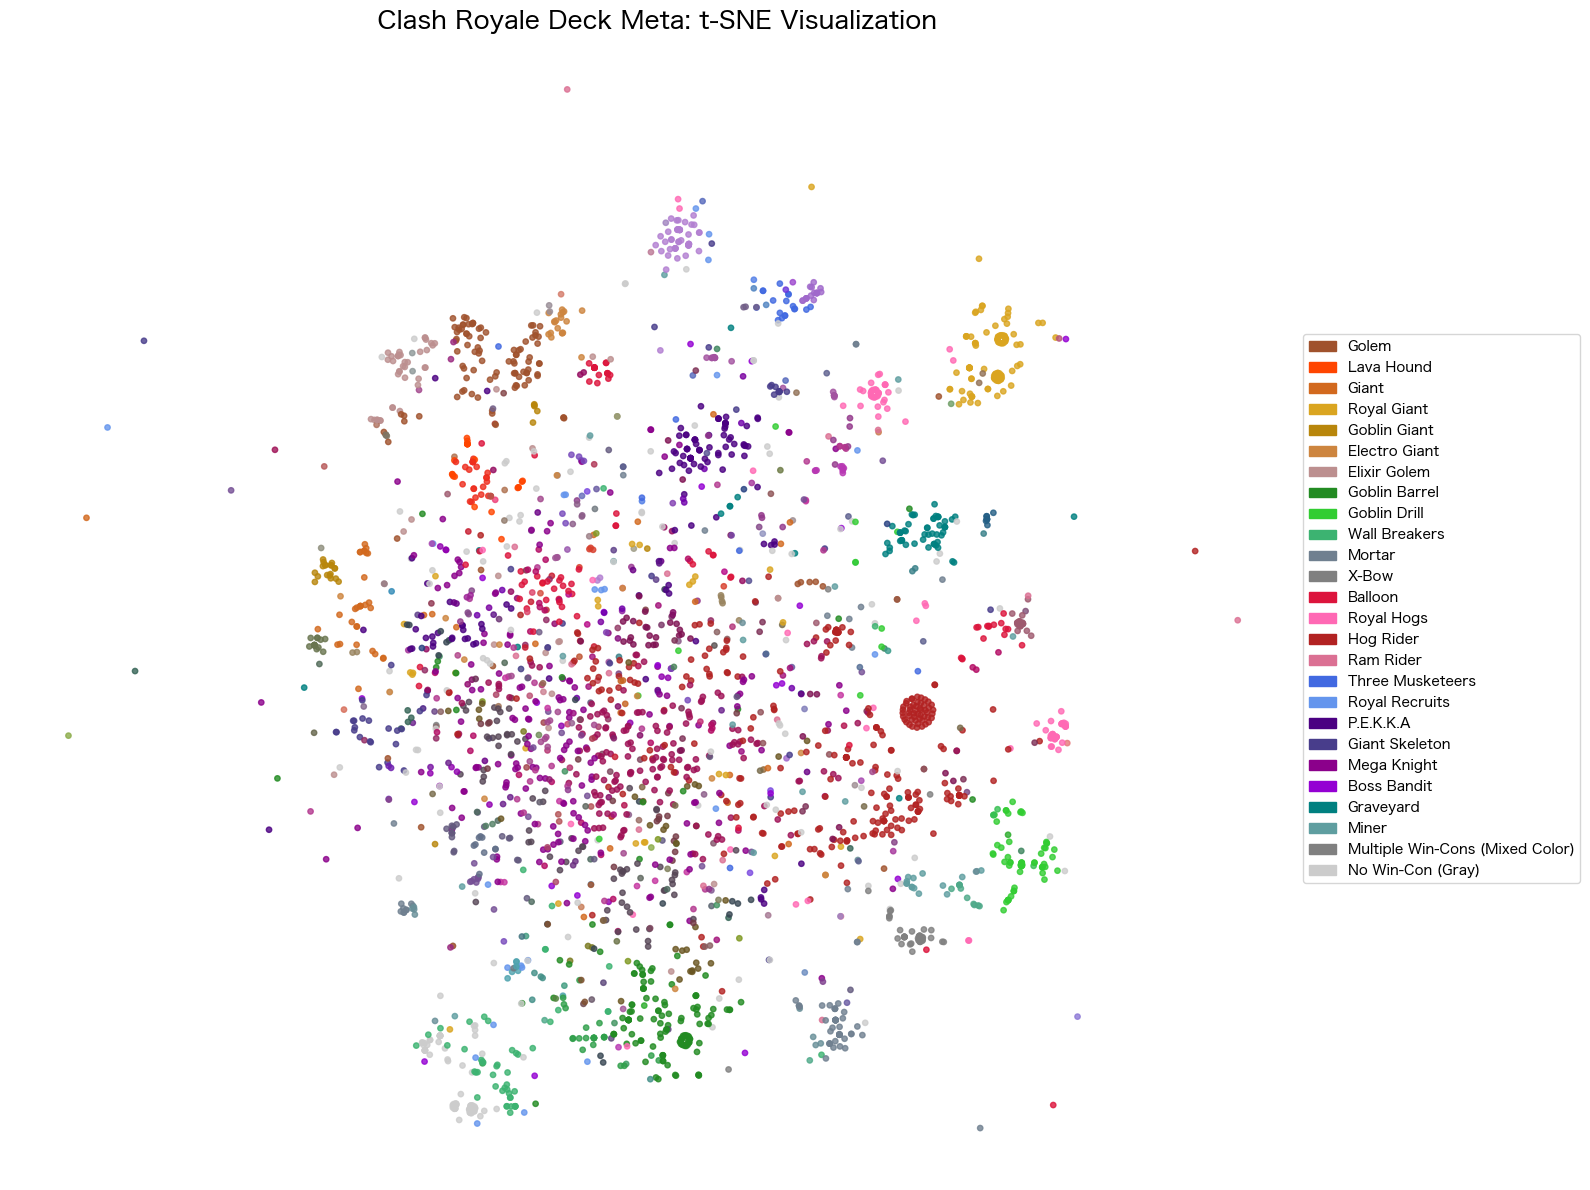

In [33]:
# ==========================================
# 1. メインカードリストの定義
# ==========================================
target_main_cards = [
    #タンク系
    "Golem",               # ゴーレム
    "Lava Hound",          # ラヴァハウンド
    "Giant",               # ジャイアント
    "Royal Giant",         # ロイヤルジャイアント
    "Goblin Giant",        # ゴブジャイアント
    "Electro Giant",       # エレクトロジャイアント
    "Elixir Golem",        # エリクサーゴーレム

    # 枯渇系
    "Goblin Barrel",       # ゴブリンバレル
    "Goblin Drill",        # ゴブリンドリル
    "Wall Breakers",       # ウォールブレイカー

    #建物系
    "Mortar",              # 迫撃砲
    "X-Bow",               # 巨大クロスボウ

    #タワー突撃系
    "Balloon",             # エアバルーン
    "Royal Hogs",          # ロイヤルホグ
    "Hog Rider",           # ホグライダー
    "Ram Rider",           # ラムライダー

    #両サイド系
    "Three Musketeers",    # 三銃士
    "Royal Recruits",      # 見習い親衛隊

    #神器系
    "P.E.K.K.A",           # ペッカ
    "Giant Skeleton",      # 巨大スケルトン
    "Mega Knight",         # メガナイト
    "Boss Bandit",         # ボスアサシン

    #その他
    "Graveyard",           # スケルトンラッシュ
    "Miner"                # ディガー
   
]

# 全デッキに登場したユニークなカード一覧
all_unique_cards = list(set([card for deck in decks_names for card in deck]))

n_samples = 3000 # 描画するデッキ数を指定
random.seed(42)

if len(decks_names) > n_samples:
    sampled_decks_names = random.sample(decks_names, n_samples)
else:
    sampled_decks_names = decks_names

print(f"全 {len(decks_names)} 件中、ランダムに抽出した {len(sampled_decks_names)} 件を処理します。")

# ==========================================
# 2. 網羅率（カバレッジ）の計算
# ==========================================
deck_win_conditions = []
for deck in sampled_decks_names:
    win_cons = [card for card in deck if card in target_main_cards]
    deck_win_conditions.append(win_cons)

zero_main = sum(1 for w in deck_win_conditions if len(w) == 0)
one_main = sum(1 for w in deck_win_conditions if len(w) == 1)
multi_main = sum(1 for w in deck_win_conditions if len(w) > 1)
total_decks = len(sampled_decks_names)

print("📊 --- 主軸カードの網羅率レポート ---")
print(f"全データ数: {total_decks} デッキ")
print(f"単一主軸デッキ: {one_main} ({one_main/total_decks*100:.1f}%)")
print(f"複数主軸デッキ: {multi_main} ({multi_main/total_decks*100:.1f}%)")
print(f"主軸なしデッキ: {zero_main} ({zero_main/total_decks*100:.1f}%)")
print(f"分類成功率（網羅率）: {(one_main + multi_main)/total_decks*100:.1f}%")
print("------------------------------------\n")

# ==========================================
# 3. デッキのベクトル化 (One-Hot Encoding)
# ==========================================
print("デッキをベクトル化し、t-SNEを実行中")
card_to_idx = {card: i for i, card in enumerate(all_unique_cards)}
X = np.zeros((total_decks, len(all_unique_cards)))

for i, deck in enumerate(sampled_decks_names):
    for card in deck:
        X[i, card_to_idx[card]] = 1

# t-SNEによる2次元圧縮
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_2d = tsne.fit_transform(X)

# ==========================================
# 4. メインカード固有色を使ったカラーマッピング 
# ==========================================
# 自分でカードごとのイメージカラーを指定する（英語の色名や #FF0000 などのカラーコードが使えます）
base_colors = {
    # タンク系 (ブラウン・オレンジ・ゴールド系の重量感ある暖色)
    "Golem": to_rgb("sienna"),
    "Lava Hound": to_rgb("orangered"),
    "Giant": to_rgb("chocolate"),
    "Royal Giant": to_rgb("goldenrod"),
    "Goblin Giant": to_rgb("darkgoldenrod"),
    "Electro Giant": to_rgb("peru"),
    "Elixir Golem": to_rgb("rosybrown"),

    # 枯渇系 (ゴブリンを連想させるグリーン系)
    "Goblin Barrel": to_rgb("forestgreen"),
    "Goblin Drill": to_rgb("limegreen"),
    "Wall Breakers": to_rgb("mediumseagreen"),

    # 建物系 (無機物を連想させるグレー・シルバー系)
    "Mortar": to_rgb("slategray"),
    "X-Bow": to_rgb("gray"),

    # タワー突撃系 (ホグライダーや突進系のレッド・ピンク系)
    "Balloon": to_rgb("crimson"),
    "Royal Hogs": to_rgb("hotpink"),
    "Hog Rider": to_rgb("firebrick"),
    "Ram Rider": to_rgb("palevioletred"),

    # 両サイド系 (王室やマスケット銃士のブルー系)
    "Three Musketeers": to_rgb("royalblue"),
    "Royal Recruits": to_rgb("cornflowerblue"),

    # 神器系 (ダークで圧迫感のあるパープル・ネイビー系)
    "P.E.K.K.A": to_rgb("indigo"),
    "Giant Skeleton": to_rgb("darkslateblue"),
    "Mega Knight": to_rgb("darkmagenta"),
    "Boss Bandit": to_rgb("darkviolet"),

    # その他 (独立したシアン・青緑系)
    "Graveyard": to_rgb("teal"),
    "Miner": to_rgb("cadetblue")
}

point_colors = []
for win_cons in deck_win_conditions:
    if len(win_cons) == 0:
        point_colors.append((0.8, 0.8, 0.8, 0.3)) 
    elif len(win_cons) == 1:
        point_colors.append(base_colors[win_cons[0]]) 
    else:
        avg_color = np.mean([base_colors[wc] for wc in win_cons], axis=0)
        point_colors.append(tuple(avg_color)) # NDArrayをタプルに戻して追加

# ==========================================
# 5. 可視化 (Scatter Plot)
# ==========================================
plt.figure(figsize=(16, 12))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=15, alpha=0.8)

# 凡例（Legend）の作成
legend_patches = []
for card in target_main_cards:
    if card in all_unique_cards: 
        patch = mpatches.Patch(color=base_colors[card], label=card)
        legend_patches.append(patch)

# 複数主軸と主軸なしの凡例も追加
legend_patches.append(mpatches.Patch(color=(0.5, 0.5, 0.5), label='Multiple Win-Cons (Mixed Color)'))
legend_patches.append(mpatches.Patch(color=(0.8, 0.8, 0.8), label='No Win-Con (Gray)'))

plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.title(' Clash Royale Deck Meta: t-SNE Visualization', fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()

### 事前学習モデルのエンコードによるデッキ分類の可視化
- 結果：今回のクラスタリング手法においてtransformerによる事前学習モデルはOne-Hotエンディングに惨敗であった。
- 考察：

学習済みの重みを正常にインポートしました。
全 619647 件中、ランダムに抽出した 3000 件を処理します。
モデルの重みを使用して特徴量ベクトルを抽出中...
t-SNEによる次元削減を実行中...


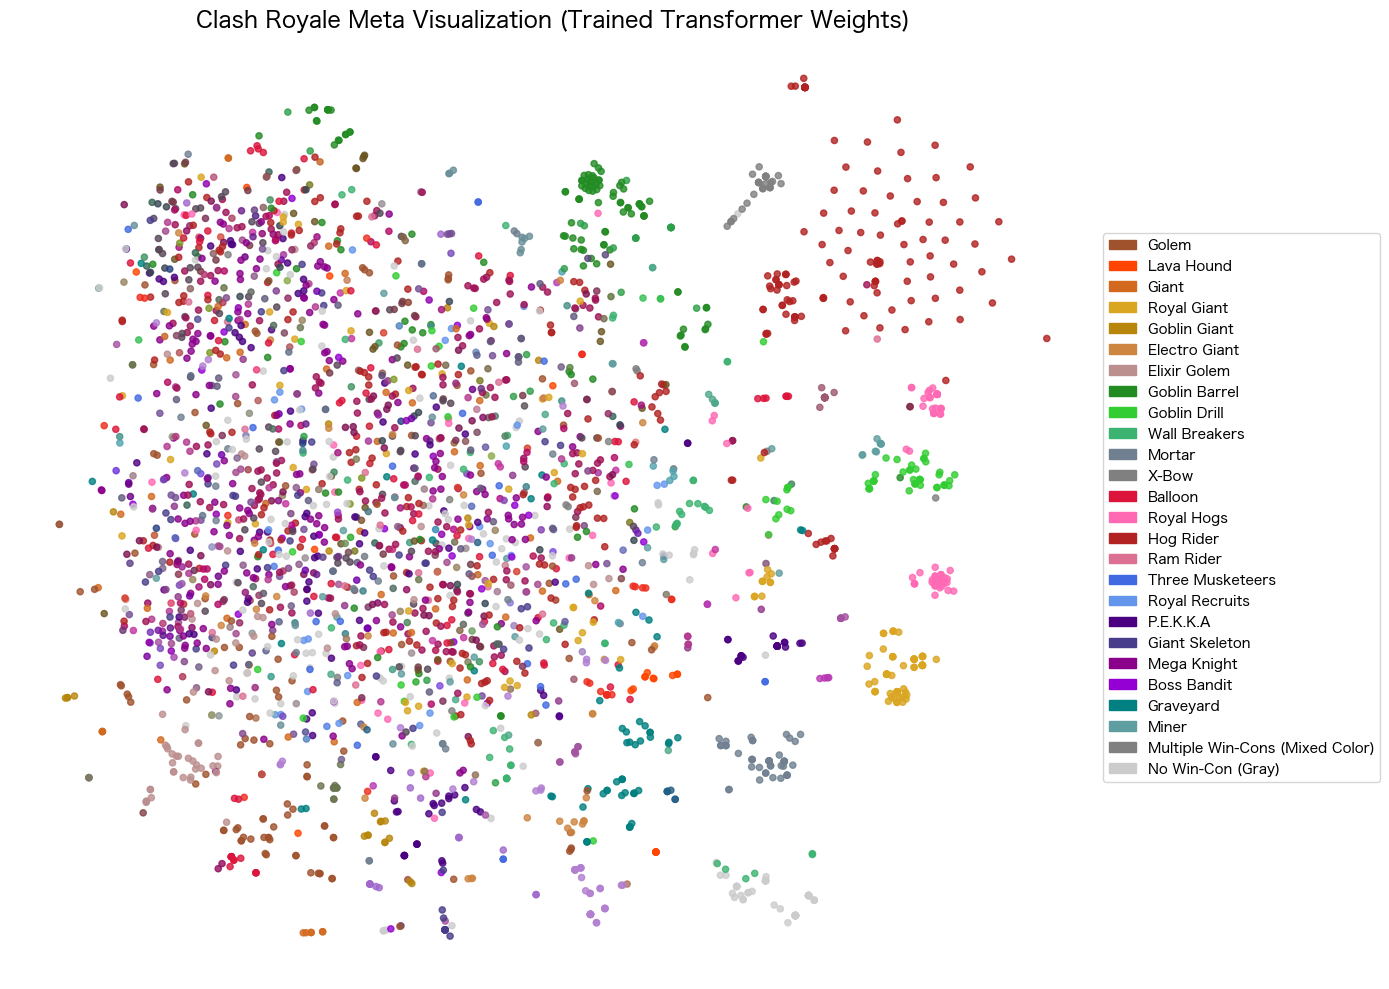

In [44]:
target_dir = '../src'
if target_dir not in sys.path:
    sys.path.append(target_dir)
from pre_train_model import DeckTransformer

# ==========================================
# 0. 辞書の準備とモデルのロード（修正箇所）
# ==========================================
# 辞書の復元
name_to_id = {name: id_val for id_val, name in id_to_name.items()}
raw_ids = list(id_to_name.keys())
id_to_idx = {raw_id: i for i, raw_id in enumerate(raw_ids)}
unk_idx = len(raw_ids)
vocab_size = len(raw_ids) + 1

# ★ モデルのインスタンス化と重みのロード
# d_modelやnheadなどのパラメータは、学習時と同じ数値を指定してください
model = DeckTransformer(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=4)

# 学習済みの重みファイル（.pth）のパスを指定して読み込む
# ※パスはご自身の環境に合わせて変更してください
model_path = '../models/deck_encoder.pth' 
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval() # 評価モードに切り替え

print("学習済みの重みを正常にインポートしました。")

# ==========================================
# 1. データのサブセット化
# ==========================================
n_samples = 3000 
random.seed(42)

if len(decks_names) > n_samples:
    sampled_decks_names = random.sample(decks_names, n_samples)
else:
    sampled_decks_names = decks_names

print(f"全 {len(decks_names)} 件中、ランダムに抽出した {len(sampled_decks_names)} 件を処理します。")

# ==========================================
# 2. サブセットに対する色の割り当て計算
# ==========================================
deck_win_conditions_subset = []
for deck in sampled_decks_names:
    win_cons = [card for card in deck if card in target_main_cards]
    deck_win_conditions_subset.append(win_cons)

point_colors_subset = []
for win_cons in deck_win_conditions_subset:
    if len(win_cons) == 0:
        point_colors_subset.append((0.8, 0.8, 0.8, 0.3)) 
    elif len(win_cons) == 1:
        point_colors_subset.append(base_colors[win_cons[0]]) 
    else:
        avg_color = np.mean([base_colors[wc] for wc in win_cons], axis=0)
        point_colors_subset.append(tuple(avg_color))

# ==========================================
# 3. Transformerモデルによる重みベクトルの抽出
# ==========================================
deck_tensors = []
for deck in sampled_decks_names:
    idx_list = [id_to_idx.get(name_to_id.get(name), unk_idx) for name in deck]
    if len(idx_list) == 8:
        deck_tensors.append(idx_list)

X_tensor = torch.tensor(deck_tensors, dtype=torch.long)

print("モデルの重みを使用して特徴量ベクトルを抽出中...")
with torch.no_grad():
    embeddings = model.embedding(X_tensor) * math.sqrt(model.d_model)
    transformer_out = model.transformer_encoder(embeddings)
    X_encoded = transformer_out.max(dim=1)[0]

X_features = X_encoded.cpu().numpy()

# ==========================================
# 4. t-SNEによる次元削減と可視化
# ==========================================
print("t-SNEによる次元削減を実行中...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_2d_transformer = tsne.fit_transform(X_features)

plt.figure(figsize=(14, 10))
plt.scatter(X_2d_transformer[:, 0], X_2d_transformer[:, 1], 
            c=point_colors_subset[:len(X_2d_transformer)], s=20, alpha=0.8)

plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.title('Clash Royale Meta Visualization (Trained Transformer Weights)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### 定量評価
- `Silhouette Score`
- `k-Nearest Neighbors Accuracy`

In [53]:
# 1. 評価用データの準備（「単一主軸」のデッキのみを抽出して評価を明確にする）
eval_indices = [i for i, wc in enumerate(deck_win_conditions_subset) if len(wc) == 1]
y_eval = np.array([deck_win_conditions_subset[i][0] for i in eval_indices])

print(f"評価対象データ: {len(y_eval)} 件 (単一主軸のデッキのみ抽出)\n")

# One-HotとTransformerそれぞれの2次元座標を抽出
try:
    X_onehot_eval = X_2d[eval_indices]
    X_trans_eval = X_2d_transformer[eval_indices]
except NameError:
    print("エラー: X_2d または X_2d_transformer が見つかりません。両方のt-SNEを実行してから再度お試しください。")
    raise

# 2. シルエットスコアの計算 (全体の分離度合い)
sil_onehot = silhouette_score(X_onehot_eval, y_eval)
sil_trans = silhouette_score(X_trans_eval, y_eval)

# 3. k-NN精度の計算 (局所的な純度、k=5で検証)
knn = KNeighborsClassifier(n_neighbors=5)

# 交差検証(5分割)でスコアを計算
knn_onehot_scores = cross_val_score(knn, X_onehot_eval, y_eval, cv=5)
knn_trans_scores = cross_val_score(knn, X_trans_eval, y_eval, cv=5)

knn_onehot_acc = knn_onehot_scores.mean() * 100
knn_trans_acc = knn_trans_scores.mean() * 100

# 4. 結果の出力
print("=== t-SNE クラスタリング評価レポート ===")
print("[1] シルエットスコア (高いほど、島が綺麗に分離している)")
print(f"  ▶ One-Hot Encoding : {sil_onehot:.4f}")
print(f"  ▶ Transformer      : {sil_trans:.4f}")


print("\n[2] k-NN分類精度 (高いほど、近くに同じ戦術のデッキが集まっている)")
print(f"  ▶ One-Hot Encoding : {knn_onehot_acc:.1f} %")
print(f"  ▶ Transformer      : {knn_trans_acc:.1f} %")

評価対象データ: 1715 件 (単一主軸のデッキのみ抽出)

=== t-SNE クラスタリング評価レポート ===
[1] シルエットスコア (高いほど、島が綺麗に分離している)
  ▶ One-Hot Encoding : -0.0073
  ▶ Transformer      : -0.1823

[2] k-NN分類精度 (高いほど、近くに同じ戦術のデッキが集まっている)
  ▶ One-Hot Encoding : 77.7 %
  ▶ Transformer      : 54.1 %


### 分類クラスごとの定量評価

In [54]:
# 1. k-NNモデルの準備
knn = KNeighborsClassifier(n_neighbors=5)

# 2. 交差検証を使って、各デッキに対する「予測ラベル」を生成
# （自分自身の答えを見ずに、周りの5つの点から自分が何のデッキか推測させる）
y_pred_onehot = cross_val_predict(knn, X_onehot_eval, y_eval, cv=5)
y_pred_trans  = cross_val_predict(knn, X_trans_eval, y_eval, cv=5)

# 3. レポートの出力
print("======================================================")
print("クラス別 分類評価レポート (One-Hot Encoding)")
print("======================================================")
# zero_division=0 は、データが少なすぎて計算できないクラスのエラーを防ぎます
print(classification_report(y_eval, y_pred_onehot, zero_division=0))

print("\n\n======================================================")
print("クラス別 分類評価レポート (Transformer)")
print("======================================================")
print(classification_report(y_eval, y_pred_trans, zero_division=0))

クラス別 分類評価レポート (One-Hot Encoding)
                  precision    recall  f1-score   support

         Balloon       0.61      0.82      0.70        78
     Boss Bandit       0.14      0.10      0.11        21
   Electro Giant       0.69      0.55      0.61        33
    Elixir Golem       0.63      0.68      0.66        56
           Giant       0.76      0.63      0.69        46
  Giant Skeleton       0.67      0.64      0.65        50
   Goblin Barrel       0.83      0.86      0.85       135
    Goblin Drill       0.92      0.88      0.90        68
    Goblin Giant       0.77      0.92      0.84        26
           Golem       0.89      0.83      0.86       105
       Graveyard       0.90      0.90      0.90        62
       Hog Rider       0.79      0.89      0.84       287
      Lava Hound       0.87      0.95      0.91        21
     Mega Knight       0.67      0.71      0.69       154
           Miner       0.80      0.43      0.56        28
          Mortar       0.87      0.80 

### デッキのコストに関する統計的特徴量

In [41]:
# ==========================================
# 1. JSONからコスト情報を読み込み、名前に紐づける
# ==========================================
# ※実際の cards.json のパスに合わせて書き換えてください
json_file_path = '../data/cards.json' 

with open(json_file_path, 'r', encoding='utf-8') as f:
    cards_data = json.load(f)

# カード名 -> コスト に変換する辞書を自動生成
name_to_cost = {}
for card_id, name in id_to_name.items():
    # JSONのキーは文字列として保存されていることが多いので str() で合わせる
    card_info = cards_data.get(str(card_id), {})
    
    # elixircost を取得（万が一データ欠損があればデフォルトで3とする）
    cost = card_info.get('elixirCost', 3)
    name_to_cost[name] = cost

print(f"✅ JSONから {len(name_to_cost)} 枚のカードコスト情報を読み込みました。")

# ==========================================
# 2. 各デッキの平均コストを計算
# ==========================================
deck_costs = []
for deck in sampled_decks_names:
    total_cost = sum(name_to_cost.get(card, 3) for card in deck)
    deck_costs.append(total_cost / 8.0)

# ==========================================
# 3. 統計的特徴量の出力
# ==========================================
cost_series = pd.Series(deck_costs, name="Deck Average Cost")

print("\n=== 📊 デッキ平均コストの統計的特徴量 ===")
print(cost_series.describe().round(3))

print("\n--- 追加の統計量 ---")
print(f"分散 (Variance): {cost_series.var():.3f}  <- データのばらつき具合")
print(f"歪度 (Skewness): {cost_series.skew():.3f}  <- 偏り (正なら重いデッキ側に裾が広い)")
print(f"尖度 (Kurtosis): {cost_series.kurt():.3f}  <- 尖り具合 (特定コスト帯への集中度)")

✅ JSONから 121 枚のカードコスト情報を読み込みました。

=== 📊 デッキ平均コストの統計的特徴量 ===
count    3000.000
mean        3.616
std         0.552
min         1.750
25%         3.250
50%         3.625
75%         4.000
max         5.875
Name: Deck Average Cost, dtype: float64

--- 追加の統計量 ---
分散 (Variance): 0.305  <- データのばらつき具合
歪度 (Skewness): 0.068  <- 偏り (正なら重いデッキ側に裾が広い)
尖度 (Kurtosis): -0.060  <- 尖り具合 (特定コスト帯への集中度)
